## Imports

In [2]:
import torch
from torch.utils.data import DataLoader
from data import ParenthesizationDataset
from model import Model
from train import train_one_epoch, compute_validation_loss
from evaluate import evaluate_model, predict
from interpret import plot_linear_layer, incorrect_predictions, token_contributions, activations
import matplotlib.pyplot as plt

## Initialize model, loaders, loss function, optimizer
`checkpoint_epochs` is the number of epochs before a checkpoint is saved. Use `data_prefix` to choose the "small" dataset.

In [2]:
epochs = 20
checkpoint_epochs = 2
batch_size = 64
d_model = 16
nhead = 4
num_layers = 1
n_vocab = 4
data_prefix = "small_"

training_dataset = ParenthesizationDataset(f"{data_prefix}training")
validation_dataset = ParenthesizationDataset(f"{data_prefix}validation")
test_dataset = ParenthesizationDataset(f"{data_prefix}test")

training_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

model = Model(n_vocab, d_model, nhead, num_layers)
loss_fn = torch.nn.CrossEntropyLoss(reduction="sum")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train model
`start_epoch` can be set to a value greater than 0 to resume training from a checkpoint.

In [3]:
start_epoch = 0

training_loss = []
validation_loss = []
best_validation_loss = float("inf")

def save():
    torch.save({
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict(),
      'training_loss': training_loss,
      'validation_loss': validation_loss
    }, f"checkpoints/epoch_{epoch}.pth")

def resume(epoch):
    global training_loss, validation_loss
    checkpoint = torch.load(f"checkpoints/epoch_{epoch}.pth")
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    training_loss = checkpoint["training_loss"]
    validation_loss = checkpoint["validation_loss"]

if start_epoch > 0:
    resume(start_epoch)
    start_epoch += 1

for epoch in range(start_epoch, epochs):
    model.train(True)
    training_loss.append(train_one_epoch(training_loader, model, loss_fn, optimizer))
    validation_loss.append(compute_validation_loss(validation_loader, model, loss_fn))
    print(f"Epoch {epoch}, Training Loss {training_loss[-1]}, Validation Loss {validation_loss[-1]}")

    if (epoch+1) % checkpoint_epochs == 0:
        save()

Epoch 0, Training Loss 0.7011173420103308, Validation Loss 0.6883047842511943
Epoch 1, Training Loss 0.6408833496757781, Validation Loss 0.48400985727123186
Epoch 2, Training Loss 0.4172082231745659, Validation Loss 0.3980986066893035
Epoch 3, Training Loss 0.32319014607880514, Validation Loss 0.27598607072643205
Epoch 4, Training Loss 0.25483224773581115, Validation Loss 0.24731516604330026
Epoch 5, Training Loss 0.2130646664270597, Validation Loss 0.2429051819969626
Epoch 6, Training Loss 0.20734493600400714, Validation Loss 0.2955194361069623
Epoch 7, Training Loss 0.17106928574335117, Validation Loss 0.24816106814964145
Epoch 8, Training Loss 0.1460051601860339, Validation Loss 0.20060532700781727
Epoch 9, Training Loss 0.1411776292345833, Validation Loss 0.15466438672121832
Epoch 10, Training Loss 0.1459921561430956, Validation Loss 0.19277355483933992
Epoch 11, Training Loss 0.13173254366626264, Validation Loss 0.08370536741088419
Epoch 12, Training Loss 0.10325090822038749, Vali

# Plot the loss curve for training and validation

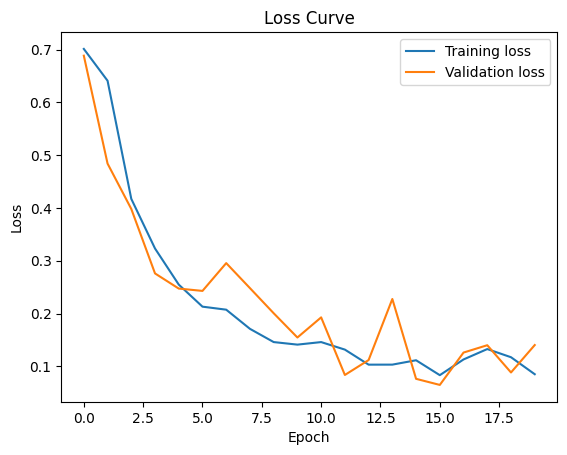

In [5]:
# Plot loss function
plt.plot(training_loss, label="Training loss")
plt.plot(validation_loss, label="Validation loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()

# Evaluate the model and plot the confusion matrix

[[1547, 95], [0, 1644]]
Training data set accuracy:
Accuracy for class 0 = 94.21437271619976%
Accuracy for class 1 = 100.0%
Overall accuracy = 97.10894704808277%


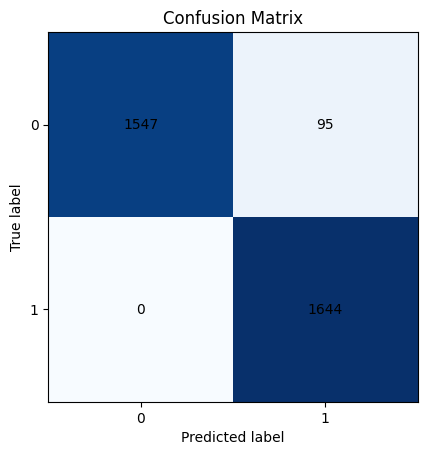

Validation data set accuracy:
Accuracy for class 0 = 95.09803921568627%
Accuracy for class 1 = 100.0%
Overall accuracy = 97.54901960784314%


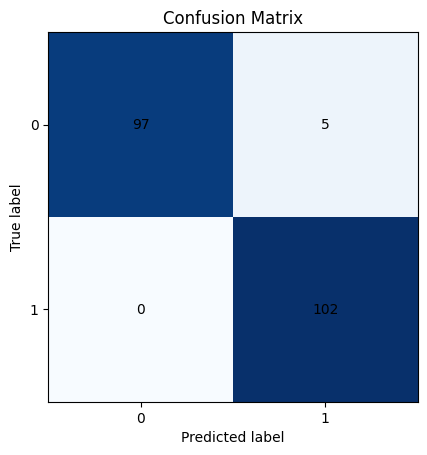

Test data set accuracy:
Accuracy for class 0 = 94.8051948051948%
Accuracy for class 1 = 100.0%
Overall accuracy = 97.40259740259741%


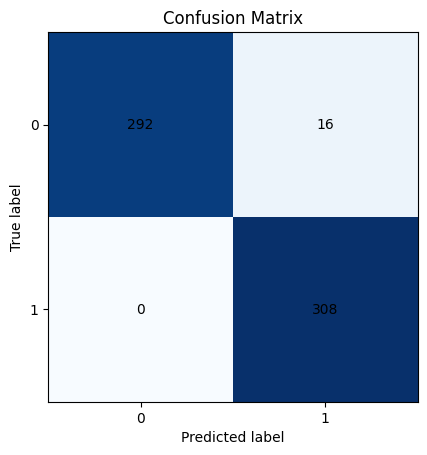

In [13]:
training_confusion_matrix = evaluate_model(model, training_loader)
validation_confusion_matrix = evaluate_model(model, validation_loader)
test_confusion_matrix = evaluate_model(model, test_loader)

print(training_confusion_matrix)

print("Training data set accuracy:")
training_confusion_matrix.print_accuracy()
training_confusion_matrix.plot()

print("Validation data set accuracy:")
validation_confusion_matrix.print_accuracy()
validation_confusion_matrix.plot()

print("Test data set accuracy:")
test_confusion_matrix.print_accuracy()
test_confusion_matrix.plot()

# Interpretation
In this section you will try various techniques to interpret the model. Insert additional notebook cells as need to do the following:

1. Construct some test cases of varying lengths and display the model's predictions.
2. Compute the list of incorrect predictions and display some examples of them.
3. For each incorrect prediction, plot the token contributions as a heatmap.
4. For each position from 0 to 21, loop over all inputs in the test set and plot a histogram of the token contributions for that position.
5. Plot the heatmap for the projection layer and the second linear layer in the feedforward.
6. Loop over all inputs in the test set and count the activations in the feedforward layer. Plot the activations as a histogram to see which features in the feedforward layer are activated the most.

# Interpret Part 1: Test Cases



Epoch 0, Training Loss 0.7060083701562678, Validation Loss 0.6979015761730718
Epoch 1, Training Loss 0.6920342242217108, Validation Loss 0.6860970749574549
Epoch 2, Training Loss 0.6492933817774657, Validation Loss 0.7018222715340409
Epoch 3, Training Loss 0.5255233396935304, Validation Loss 0.43826697153203625
Epoch 4, Training Loss 0.43527568975600683, Validation Loss 0.3913145532795027
Epoch 5, Training Loss 0.38283606933807357, Validation Loss 0.3459316141465131
Epoch 6, Training Loss 0.35607398231074494, Validation Loss 0.37681759338752896
Epoch 7, Training Loss 0.32483337713463306, Validation Loss 0.28047969762016745
Epoch 8, Training Loss 0.2739622743842229, Validation Loss 0.24376780612795962
Epoch 9, Training Loss 0.2309291834375587, Validation Loss 0.23500769044838699
Epoch 10, Training Loss 0.22474163505846745, Validation Loss 0.2428245509372038
Epoch 11, Training Loss 0.18216514594657932, Validation Loss 0.16439729812098483
Epoch 12, Training Loss 0.1790567563934001, Valida

C:\Users\said1210\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\nn\modules\transformer.py:408: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ..\aten\src\ATen\NestedTensorImpl.cpp:180.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


Training data set accuracy:
Accuracy for class 0 = 93.23995127892813%
Accuracy for class 1 = 98.72262773722628%
Overall accuracy = 95.98295800365186%


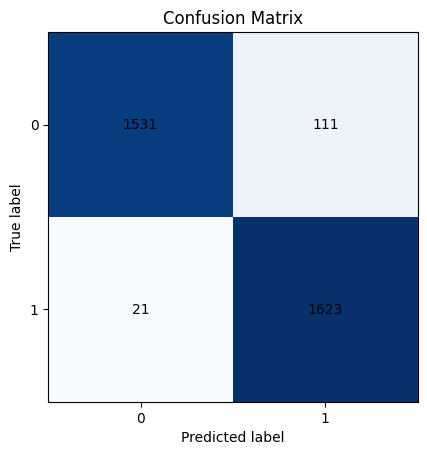

Validation data set accuracy:
Accuracy for class 0 = 94.11764705882354%
Accuracy for class 1 = 97.05882352941177%
Overall accuracy = 95.58823529411765%


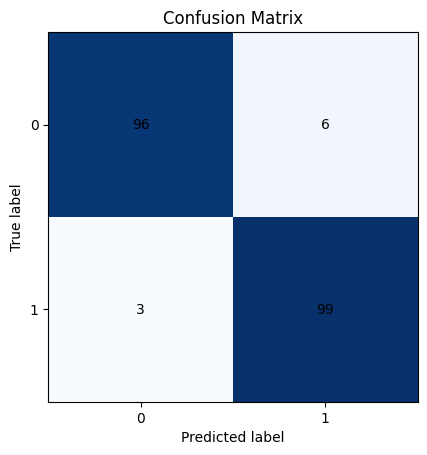

Test data set accuracy:
Accuracy for class 0 = 93.50649350649351%
Accuracy for class 1 = 97.07792207792208%
Overall accuracy = 95.29220779220779%


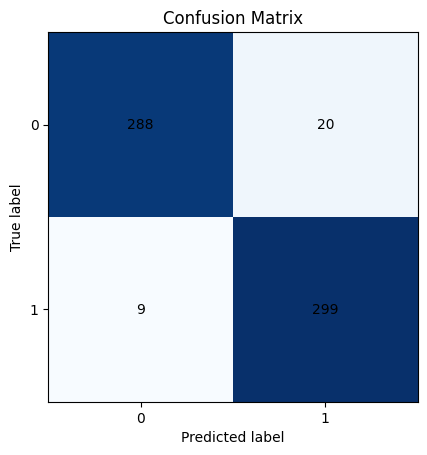

In [3]:
#Train Data, Create Model, and show preictions
epochs = 20
checkpoint_epochs = 2
batch_size = 64
d_model = 16
nhead = 4
num_layers = 1
n_vocab = 4
data_prefix = "small_"

training_dataset = ParenthesizationDataset(f"{data_prefix}training")
validation_dataset = ParenthesizationDataset(f"{data_prefix}validation")
test_dataset = ParenthesizationDataset(f"{data_prefix}test")

training_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

model = Model(n_vocab, d_model, nhead, num_layers)
loss_fn = torch.nn.CrossEntropyLoss(reduction="sum")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


start_epoch = 0

training_loss = []
validation_loss = []
best_validation_loss = float("inf")

def save():
    torch.save({
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict(),
      'training_loss': training_loss,
      'validation_loss': validation_loss
    }, f"checkpoints/epoch_{epoch}.pth")

def resume(epoch):
    global training_loss, validation_loss
    checkpoint = torch.load(f"checkpoints/epoch_{epoch}.pth")
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    training_loss = checkpoint["training_loss"]
    validation_loss = checkpoint["validation_loss"]

if start_epoch > 0:
    resume(start_epoch)
    start_epoch += 1

for epoch in range(start_epoch, epochs):
    model.train(True)
    training_loss.append(train_one_epoch(training_loader, model, loss_fn, optimizer))
    validation_loss.append(compute_validation_loss(validation_loader, model, loss_fn))
    print(f"Epoch {epoch}, Training Loss {training_loss[-1]}, Validation Loss {validation_loss[-1]}")

    if (epoch+1) % checkpoint_epochs == 0:
        save()


training_confusion_matrix = evaluate_model(model, training_loader)
validation_confusion_matrix = evaluate_model(model, validation_loader)
test_confusion_matrix = evaluate_model(model, test_loader)

print("Training data set accuracy:")
training_confusion_matrix.print_accuracy()
training_confusion_matrix.plot()

print("Validation data set accuracy:")
validation_confusion_matrix.print_accuracy()
validation_confusion_matrix.plot()

print("Test data set accuracy:")
test_confusion_matrix.print_accuracy()
test_confusion_matrix.plot()

# Part Two: List of Incorrect Predictions

In [4]:
incorrect_predictionsTrain = incorrect_predictions(model, training_loader)

AttributeError: 'Model' object has no attribute 'device'